🟢 Step 1 : Import Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

sns.set_style("whitegrid")

Step 2 : Load Dataset

In [4]:
df = pd.read_csv("messy_dataset_large.csv")

Step 3 : Display Dataset

In [5]:
df.head(10)

,Name,Email,Phone,Age,City,Join_Date,Comment
0,Aarav Sharma,aarav.sharma@gmail.com,9876543210,24.0,Pune,12/05/2024,Excellent!!! employee
1,Riya Patel,riya@@gmail.com,+91-98765-43210,NaN,Mumbai,2024-05-13,Needs@@review
2,Kabir Singh,kabir.singh@gmail.com,98765 43210,29.0,mumbai,13-05-2024,Good worker
3,Ananya Gupta,ananya@gmail,987654321,26.0,Delhi,2024/05/14,Excellent###
4,Ananya Gupta,ananya@gmail,987654321,26.0,Delhi,2024/05/14,Excellent###
5,Vivaan Mehta,vivaan@yahoo.com,(987)654-3210,31.0,Ahmedabad,15/05/2024,Top performer!!!
6,Meera Joshi,meera@gmail.com,9123456789,22.0,Jaipur,2024-05-16,Pending...
7,Arjun Nair,arjun@hotmail.com,99999-88888,27.0,Surat,16-05-2024,Nice$$$
8,Diya Verma,diya@gmail.com,+91 9988776655,23.0,Pune,2024.05.17,Excellent employee!!
9,Ishaan Rao,ishaan@gmail.com,8877665544,30.0,Nashik,17/05/2024,Average%%%


Step 4 : Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Name       20 non-null     object 
 1   Email      20 non-null     object 
 2   Phone      20 non-null     object 
 3   Age        18 non-null     float64
 4   City       20 non-null     object 
 5   Join_Date  20 non-null     object 
 6   Comment    20 non-null     object 
dtypes: float64(1), object(6)
memory usage: 1.2+ KB


Step 5 : Shape

In [7]:
print(df.shape)

(20, 7)


Step 6 : Missing Values

In [8]:
df.isnull().sum()

Name         0
Email        0
Phone        0
Age          2
City         0
Join_Date    0
Comment      0
dtype: int64

Step 7 : Duplicate Rows

In [9]:
df.duplicated().sum()

np.int64(1)

Step 8 : Before Cleaning Visualization

City Distribution

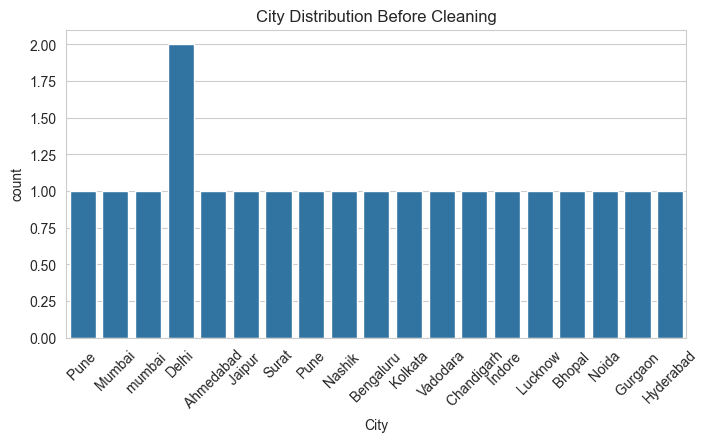

In [10]:
plt.figure(figsize=(8,4))

sns.countplot(data=df,x="City")

plt.xticks(rotation=45)

plt.title("City Distribution Before Cleaning")

plt.show()

Age Distribution

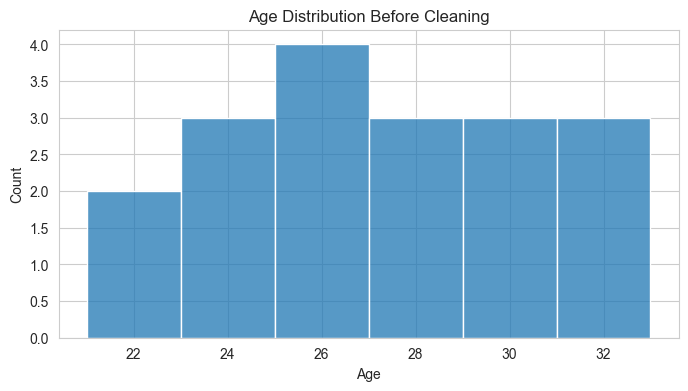

In [11]:
plt.figure(figsize=(8,4))

sns.histplot(df["Age"])

plt.title("Age Distribution Before Cleaning")

plt.show()

Step 9 : Fill Missing Values

In [12]:
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

df["Age"] = df["Age"].fillna(df["Age"].mean())

Step 10 : Remove Duplicate Rows

In [13]:
df.drop_duplicates(inplace=True)

Step 11 : Remove Extra Spaces

In [14]:
df["Name"] = df["Name"].str.strip()

df["City"] = df["City"].str.strip()

df["Comment"] = df["Comment"].str.strip()

Step 12 : Convert Text to Lowercase

In [15]:
df["Name"] = df["Name"].str.lower()

df["City"] = df["City"].str.lower()

Step 13 : Regex - Clean Phone Numbers

In [16]:
df["Phone"] = df["Phone"].astype(str)

df["Phone"] = df["Phone"].str.replace(r"\D","",regex=True)

Step 14 : Regex - Remove Special Characters

In [17]:
df["Comment"] = df["Comment"].str.replace(r"[^A-Za-z0-9 ]","",regex=True)

Step 15 : Regex - Remove Extra Spaces in Comments

In [18]:
df["Comment"] = df["Comment"].str.replace(r"\s+"," ",regex=True)

Step 16 : Regex - Validate Email

In [19]:
pattern = r'^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$'

df["Valid_Email"] = df["Email"].apply(
    lambda x: "Valid" if re.match(pattern,str(x)) else "Invalid"
)

Step 17 : Standardize Date Format

In [20]:
df["Join_Date"] = pd.to_datetime(df["Join_Date"],errors="coerce")

df["Join_Date"] = df["Join_Date"].dt.strftime("%d-%m-%Y")

Step 18 : Display Cleaned Dataset

In [21]:
df.head(20)

,Name,Email,Phone,Age,City,Join_Date,Comment,Valid_Email
0,aarav sharma,aarav.sharma@gmail.com,9876543210,24.000000,pune,05-12-2024,Excellent employee,Valid
1,riya patel,riya@@gmail.com,919876543210,26.833333,mumbai,NaN,Needsreview,Invalid
2,kabir singh,kabir.singh@gmail.com,9876543210,29.000000,mumbai,NaN,Good worker,Valid
3,ananya gupta,ananya@gmail,987654321,26.000000,delhi,NaN,Excellent,Invalid
5,vivaan mehta,vivaan@yahoo.com,9876543210,31.000000,ahmedabad,NaN,Top performer,Valid
6,meera joshi,meera@gmail.com,9123456789,22.000000,jaipur,NaN,Pending,Valid
7,arjun nair,arjun@hotmail.com,9999988888,27.000000,surat,NaN,Nice,Valid
8,diya verma,diya@gmail.com,919988776655,23.000000,pune,NaN,Excellent employee,Valid
9,ishaan rao,ishaan@gmail.com,8877665544,30.000000,nashik,NaN,Average,Valid
10,sneha kulkarni,sneha.k@gmail.com,9012345678,25.000000,bengaluru,NaN,Hardworking,Valid


Step 19 : Missing Values After Cleaning

In [22]:
df.isnull().sum()

Name            0
Email           0
Phone           0
Age             0
City            0
Join_Date      18
Comment         0
Valid_Email     0
dtype: int64

Step 20 : After Cleaning Visualization

Email Validation

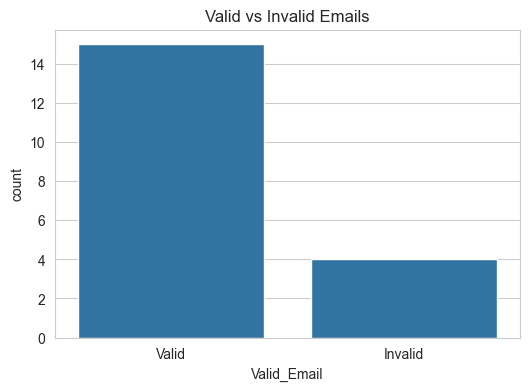

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Valid_Email")

plt.title("Valid vs Invalid Emails")

plt.show()

Age Distribution

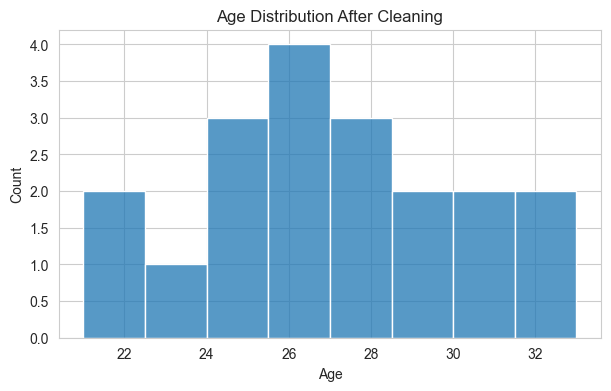

In [24]:
plt.figure(figsize=(7,4))

sns.histplot(df["Age"],bins=8)

plt.title("Age Distribution After Cleaning")

plt.show()

City Distribution

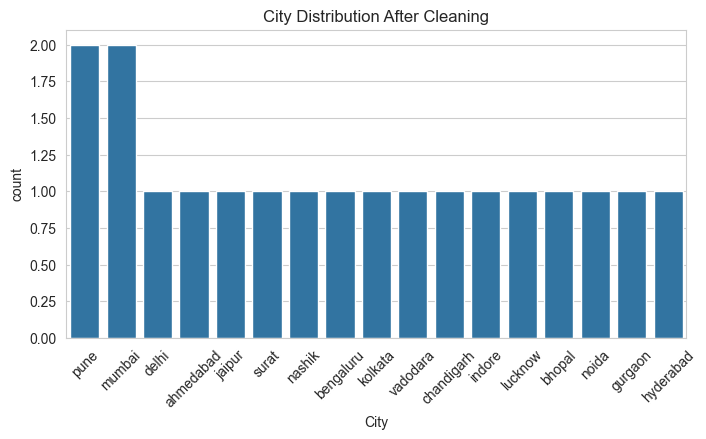

In [25]:
plt.figure(figsize=(8,4))

sns.countplot(data=df,x="City")

plt.xticks(rotation=45)

plt.title("City Distribution After Cleaning")

plt.show()

Step 21 : Save Clean Dataset

In [26]:
df.to_csv("cleaned_dataset.csv",index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


Step 22 : Final Summary

In [27]:
print("="*50)
print("DATA CLEANING COMPLETED SUCCESSFULLY")
print("="*50)

print("\nFinal Shape :",df.shape)

print("\nMissing Values")

print(df.isnull().sum())

print("\nDuplicate Rows :",df.duplicated().sum())

DATA CLEANING COMPLETED SUCCESSFULLY

Final Shape : (19, 8)

Missing Values
Name            0
Email           0
Phone           0
Age             0
City            0
Join_Date      18
Comment         0
Valid_Email     0
dtype: int64

Duplicate Rows : 0
